# Feature Engine - Topic 09 - Custom functions for Data Cleaning and Feature Engineering Workflow

## <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> Topic Objectives

* Understand and use custom functions for data cleaning and feature engineering workflow, using feature-engine transformers



---

## <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> Import Packages for Learning

And load our typical packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.pipeline import Pipeline

---

## <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Custom functions for Data Cleaning and Feature Engineering Workflow

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> You probably noticed the exercises from previous the topics took time and energy as there is no one fixed recipe but instead just guidelines.
* This is the reason that data practitioners spend a lot of energy and time in data cleaning and feature engineering the variables


<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Result.png
"> We created a custom function, made with specific feature-engine transformers, to help you be more effective during the Data Cleaning and Feature Engineering stage. We will instruct you on how we expect you to use and interpret it.

* We will present two functions to you now, and we will use them in future practice.
  * `DataCleaningEffect()`
  * `FeatureEngineeringAnalysis()`


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> These custom functions were delivered specially for this course. The functions' logic and usability have been tested and reviewed extensively; however, bugs may exist.



---

* We will not focus on explaining the code itself but focus on the functionality and instruct how we could use it

<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Challenge%20test.png
">
 `DataCleaningEffect()`
* Function objective: assess the effect of cleaning the data, when:
  * imput mean, median or arbitrary number is a numerical variable
  * replace with 'Missing' or most frequent a categorical variable
* Parameters: `df_original`: data not cleaned, `df_cleaned`: cleaned data,`variables_applied_with_method`: variables where you applied a given method

  * It is understandable if, at first, you don't understand all the code used in the function below. The point is to make sense of the pseudo-code and understand the function parameters.

In [2]:
def DataCleaningEffect(df_original, df_cleaned, variables_applied_with_method):
    """
    This function compares the distribution of variables before and after data cleaning.

    Parameters:
    df_original (DataFrame): The original DataFrame before cleaning.
    df_cleaned (DataFrame): The DataFrame after cleaning.
    variables_applied_with_method (list): The list of variables that the cleaning method was applied to.
    """

    flag_count = 1  # Counter to keep track of the plot number

    # Identify categorical variables in the original DataFrame
    categorical_variables = df_original.select_dtypes(exclude=['number']).columns

    # Loop over the variables that the cleaning method was applied to
    for set_of_variables in [variables_applied_with_method]:
        print("\n=====================================================================================")
        print(f"* Distribution Effect Analysis After Data Cleaning Method in the following variables:")
        print(f"{set_of_variables} \n\n")

        # For each variable, plot its distribution before and after cleaning
        for var in set_of_variables:
            if var in categorical_variables:  # If the variable is categorical, use a barplot
                # Create DataFrames for the original and cleaned data
                df1 = pd.DataFrame({"Type": "Original", "Value": df_original[var]})
                df2 = pd.DataFrame({"Type": "Cleaned", "Value": df_cleaned[var]})
                # Concatenate the two DataFrames
                dfAux = pd.concat([df1, df2], axis=0).reset_index()
                # Create the plot
                fig, axes = plt.subplots(figsize=(15, 5))
                sns.countplot(hue='Type', data=dfAux, x="Value", palette=['#432371', "#FAAE7B"])
                axes.set(title=f"Distribution Plot {flag_count}: {var}")
                plt.xticks(rotation=90)
                plt.legend()

            else:  # If the variable is numerical, use a histogram
                # Create the plot
                fig, axes = plt.subplots(figsize=(10, 5))
                sns.histplot(data=df_original, x=var, color="#432371", label='Original', kde=True, element="step", ax=axes)
                sns.histplot(data=df_cleaned, x=var, color="#FAAE7B", label='Cleaned', kde=True, element="step", ax=axes)
                axes.set(title=f"Distribution Plot {flag_count}: {var}")
                plt.legend()


---


<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Challenge%20test.png
">
 `FeatureEngineeringAnalysis()`
* Function objective: apply a set of transformers, defined by the user, for a given set of variables
* Parameters: `df`: data, `analysis_type`:` ['numerical', 'ordinal_encoder',  'outlier_winsorizer']`


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> You should parse the proper variable data types according to your analysis, for example, you shall parse only numerical variables when selecting 'numerical' for analysis_type

  * It is understandable if, at first, you don't understand all the code used in the function below. The point is to make sense of the pseudo-code and understand the function parameters.

In [3]:
import warnings
from feature_engine import transformation as vt
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OrdinalEncoder
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')


def FeatureEngineeringAnalysis(df, analysis_type=None):
    """
    - used for quick feature engineering on numerical and categorical variables
    to decide which transformation can better transform the distribution shape
    - Once transformed, use a reporting tool, like pandas-profiling, to evaluate distributions

    """
    check_missing_values(df)
    allowed_types = ['numerical', 'ordinal_encoder', 'outlier_winsorizer']
    check_user_entry_on_analysis_type(analysis_type, allowed_types)
    list_column_transformers = define_list_column_transformers(analysis_type)

    # Loop over each variable and engineer the data according to the analysis type
    df_feat_eng = pd.DataFrame([])
    for column in df.columns:
        # create additional columns (column_method) to apply the methods
        df_feat_eng = pd.concat([df_feat_eng, df[column]], axis=1)
        for method in list_column_transformers:
            df_feat_eng[f"{column}_{method}"] = df[column]

        # Apply transformers in respectives column_transformers
        df_feat_eng, list_applied_transformers = apply_transformers(
            analysis_type, df_feat_eng, column)

        # For each variable, assess how the transformations perform
        transformer_evaluation(
            column, list_applied_transformers, analysis_type, df_feat_eng)

    return df_feat_eng


def check_user_entry_on_analysis_type(analysis_type, allowed_types):
    # Check analyis type
    if analysis_type is None:
        raise SystemExit(
            f"You should pass analysis_type parameter as one of the following options: {allowed_types}")
    if analysis_type not in allowed_types:
        raise SystemExit(
            f"analysis_type argument should be one of these options: {allowed_types}")


def check_missing_values(df):
    if df.isna().sum().sum() != 0:
        raise SystemExit(
            f"There is missing values in your dataset. Please handle that before getting into feature engineering.")


def define_list_column_transformers(analysis_type):
    # Set suffix colummns acording to analysis_type
    if analysis_type == 'numerical':
        list_column_transformers = [
            "log_e", "log_10", "reciprocal", "power", "box_cox", "yeo_johnson"]

    elif analysis_type == 'ordinal_encoder':
        list_column_transformers = ["ordinal_encoder"]

    elif analysis_type == 'outlier_winsorizer':
        list_column_transformers = ['iqr']

    return list_column_transformers


def apply_transformers(analysis_type, df_feat_eng, column):

    for col in df_feat_eng.select_dtypes(include='category').columns:
        df_feat_eng[col] = df_feat_eng[col].astype('object')

    if analysis_type == 'numerical':
        df_feat_eng, list_applied_transformers = FeatEngineering_Numerical(
            df_feat_eng, column)

    elif analysis_type == 'outlier_winsorizer':
        df_feat_eng, list_applied_transformers = FeatEngineering_OutlierWinsorizer(
            df_feat_eng, column)

    elif analysis_type == 'ordinal_encoder':
        df_feat_eng, list_applied_transformers = FeatEngineering_CategoricalEncoder(
            df_feat_eng, column)

    return df_feat_eng, list_applied_transformers


def transformer_evaluation(column, list_applied_transformers, analysis_type, df_feat_eng):
    # For each variable, assess how the transformations perform
    print(f"* Variable Analyzed: {column}")
    print(f"* Applied transformation: {list_applied_transformers} \n")
    for col in [column] + list_applied_transformers:

        if analysis_type != 'ordinal_encoder':
            DiagnosticPlots_Numerical(df_feat_eng, col)

        else:
            if col == column:
                DiagnosticPlots_Categories(df_feat_eng, col)
            else:
                DiagnosticPlots_Numerical(df_feat_eng, col)

        print("\n")


def DiagnosticPlots_Categories(df_feat_eng, col):
    plt.figure(figsize=(20, 5))
    sns.countplot(data=df_feat_eng, x=col, palette=[
                  '#432371'], order=df_feat_eng[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.suptitle(f"{col}", fontsize=30, y=1.05)
    plt.show()
    print("\n")


def DiagnosticPlots_Numerical(df, variable):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    sns.histplot(data=df, x=variable, kde=True, element="step", ax=axes[0])
    stats.probplot(df[variable], dist="norm", plot=axes[1])
    sns.boxplot(x=df[variable], ax=axes[2])

    axes[0].set_title('Histogram')
    axes[1].set_title('QQ Plot')
    axes[2].set_title('Boxplot')
    fig.suptitle(f"{variable}", fontsize=30, y=1.05)
    plt.show()


def FeatEngineering_CategoricalEncoder(df_feat_eng, column):
    list_methods_worked = []
    try:
        encoder = OrdinalEncoder(encoding_method='arbitrary', variables=[
                                 f"{column}_ordinal_encoder"])
        df_feat_eng = encoder.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_ordinal_encoder")

    except:
        df_feat_eng.drop([f"{column}_ordinal_encoder"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_OutlierWinsorizer(df_feat_eng, column):
    list_methods_worked = []

    # Winsorizer iqr
    try:
        disc = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=[f"{column}_iqr"])
        df_feat_eng = disc.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_iqr")
    except:
        df_feat_eng.drop([f"{column}_iqr"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_Numerical(df_feat_eng, column):

    list_methods_worked = []

    # LogTransformer base e
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_e"])
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_e")
    except:
        df_feat_eng.drop([f"{column}_log_e"], axis=1, inplace=True)

    # LogTransformer base 10
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_10"], base='10')
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_10")
    except:
        df_feat_eng.drop([f"{column}_log_10"], axis=1, inplace=True)

    # ReciprocalTransformer
    try:
        rt = vt.ReciprocalTransformer(variables=[f"{column}_reciprocal"])
        df_feat_eng = rt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_reciprocal")
    except:
        df_feat_eng.drop([f"{column}_reciprocal"], axis=1, inplace=True)

    # PowerTransformer
    try:
        pt = vt.PowerTransformer(variables=[f"{column}_power"])
        df_feat_eng = pt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_power")
    except:
        df_feat_eng.drop([f"{column}_power"], axis=1, inplace=True)

    # BoxCoxTransformer
    try:
        bct = vt.BoxCoxTransformer(variables=[f"{column}_box_cox"])
        df_feat_eng = bct.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_box_cox")
    except:
        df_feat_eng.drop([f"{column}_box_cox"], axis=1, inplace=True)

    # YeoJohnsonTransformer
    try:
        yjt = vt.YeoJohnsonTransformer(variables=[f"{column}_yeo_johnson"])
        df_feat_eng = yjt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_yeo_johnson")
    except:
        df_feat_eng.drop([f"{column}_yeo_johnson"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


We will present the use cases and interpretations so that you can conduct your data cleaning and feature engineering steps more effectively.

---

### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Handle missing data

We are assuming that at this moment of your project in the workplace, you know which variables require you to handle missing data

<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Challenge%20test.png
"> In this exercise for Data Cleaning, we  will follow these steps:

* 1 - Select an imputation method
* 2 - Select variables to apply the method to
* 3 - Create a separate DataFrame to apply the method
* 4 - Assess the effect on the variable distribution

Let's consider the titanic dataset. It holds passengers' records from its unique ride. 

In [4]:
df = sns.load_dataset('titanic').drop(['alive'], axis=1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


We inspect the dataset and notice there are variable data types which are `'category'`. 
* Typically, categorical variables are handled as `'object'`, but sometimes, for some reason, the data is stored as `'category'` instead. 
* Feature engine library handles the data properly when a categorical variable is an `'object'` data type. 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(4)
memory usage: 73.7+ KB


We will convert them to `'object'` data type by looping over the variables with data type as `'category'` and converting to `'object'`

In [7]:
for col in df.select_dtypes(include='category'):
  df[col] = df[col].astype('object')

We check for missing data. 
* There are numerical and categorical data with missing data

In [8]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alone            0
dtype: int64

---

#### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Numerical

Using the methods we covered, you may impute with mean, median or arbitrary.
* For our exercise, we will assume we selected median

1 - Select an imputation method

In [9]:
from feature_engine.imputation import MeanMedianImputer

2 - Select the variables to apply the method to
* You have to make sure you are using numerical variables

In [10]:
variables_method = ['age']
variables_method

['age']

3 - Create a separate DataFrame to apply the method

In [11]:
imputer = MeanMedianImputer(imputation_method='median', variables=variables_method)
df_method = imputer.fit_transform(df)



4 - Assess the effect on the variable distribution
* The function plots in the same Axes, the distribution before and after applying the method; This helps to give you insights into how different your variable would look after cleaning.
* We notice the "peak" in the variable distribution after median imputation.


* Distribution Effect Analysis After Data Cleaning Method in the following variables:
['age'] 




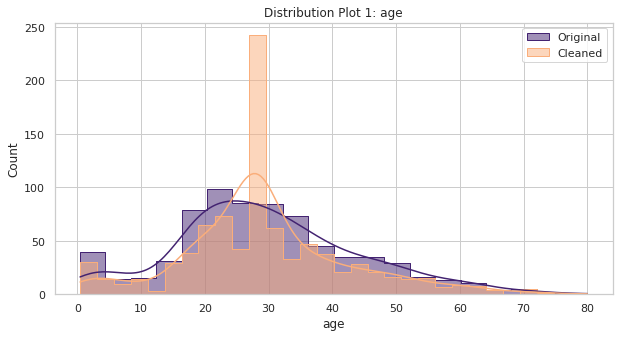

In [12]:
DataCleaningEffect(df_original=df,
                   df_cleaned=df_method,
                   variables_applied_with_method=variables_method)

---

#### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Categorical

In this exercise, we will impute 'Missing' on categorical variables 

1 - Select an imputation method

In [13]:
from feature_engine.imputation import CategoricalImputer

2 - Select variables to apply the method to
* You have to make sure you are using categorical variables

In [14]:
variables_method = ['embarked', 'deck', 'embark_town']
variables_method

['embarked', 'deck', 'embark_town']

3 - Create a separate DataFrame to apply the method

In [15]:
imputer = CategoricalImputer(imputation_method='missing',fill_value='Missing',
                             variables=variables_method)

df_method = imputer.fit_transform(df)

4 - Assess the effect on the variable distribution
* It was probably not a good idea to consider this method on these variables
  * For the deck, we might consider dropping the variable, since its missing levels are high
  * For embarked and embark_town, we may consider replacing with most frequent since the missing data levels are low.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> This exercise gives an idea of how this function works in practice.


* Distribution Effect Analysis After Data Cleaning Method in the following variables:
['embarked', 'deck', 'embark_town'] 




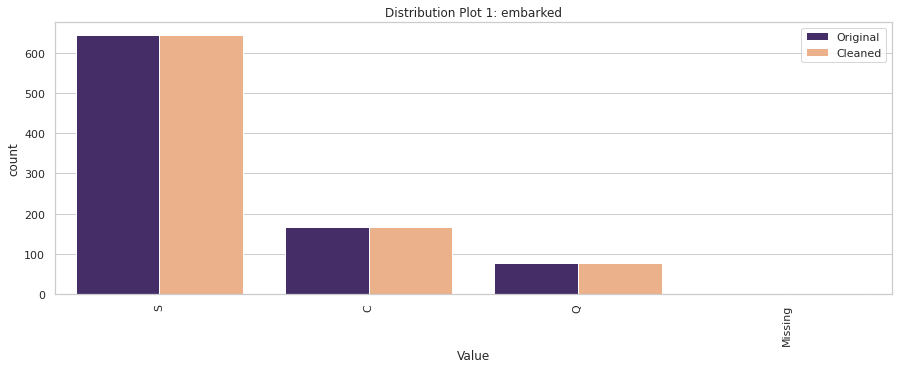

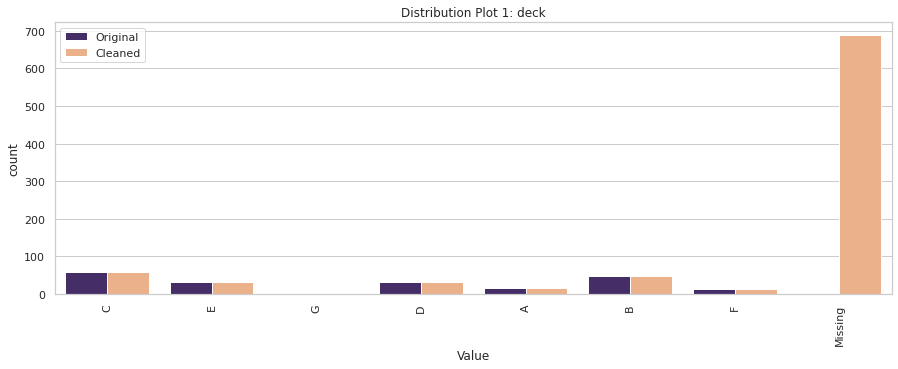

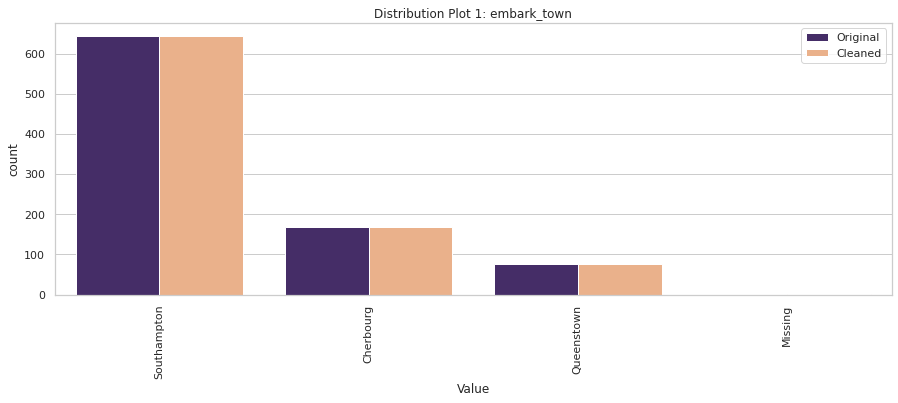

In [16]:
DataCleaningEffect(df_original=df,
                   df_cleaned=df_method,
                   variables_applied_with_method=variables_method)

---

### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Feature Engineering

<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Challenge%20test.png
"> In this exercise for Feature Engineering workflow, we will follow these steps:

* 1 - Select variable(s)
* 2 - Create a separate DataFrame, for that variable(s)
* 3 - Assess engineered variables distribution 


In your career, you will develop your preferences and unique methods for dealing with data cleaning and feature engineering. As a starting point, we suggest starting the feature engineering workflow by:
* Looking for categorical encoding
* Looking for handling outliers
* Looking for numerical transformation

---

Let's recap our dataset

In [17]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


We can check missing data levels

In [18]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alone            0
dtype: int64

In the last section, we didn't impute any missing data to the original DataFrame (df); we just checked how it would look if we applied a given imputer.
* For the next exercise, we create a quick pipeline to manage missing data, but dropping the feature with a lot of missing data, add median as imputer for age, and drop the remaining missing data

In [19]:
from sklearn.pipeline import Pipeline
from feature_engine.selection import DropFeatures
from feature_engine.imputation import MeanMedianImputer
from feature_engine.imputation import DropMissingData

data_cleaning_pipeline = Pipeline([
      ( 'DropFeatures', DropFeatures(features_to_drop=['deck']) ),
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median', variables=['age']) ),
      ( 'DropMissingData', DropMissingData()),
])

df = data_cleaning_pipeline.fit_transform(df)

We check missing data levels again
* We are good to go for feature engineering

In [20]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

---

#### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Ordinal Encoder

Again We assume that at this moment, you are on a project in the workplace; you will know which variables to encode.

1 - Select variable(s)

In [21]:
variables_engineering= ['sex', 'embarked', 'who', 'embark_town']
variables_engineering

['sex', 'embarked', 'who', 'embark_town']

2 - Create a separate DataFrame for these variables

In [22]:
df_engineering = df[variables_engineering].copy()
df_engineering.head(3)

,sex,embarked,who,embark_town
0,male,S,man,Southampton
1,female,C,woman,Cherbourg
2,female,S,woman,Southampton


3 - Assess engineered variables distribution 
* We notice that the distribution will not be normally distributed when we encode a category to a number. The new data type is numerical discrete (not continuous), and that is fine

* Variable Analyzed: sex
* Applied transformation: ['sex_ordinal_encoder'] 



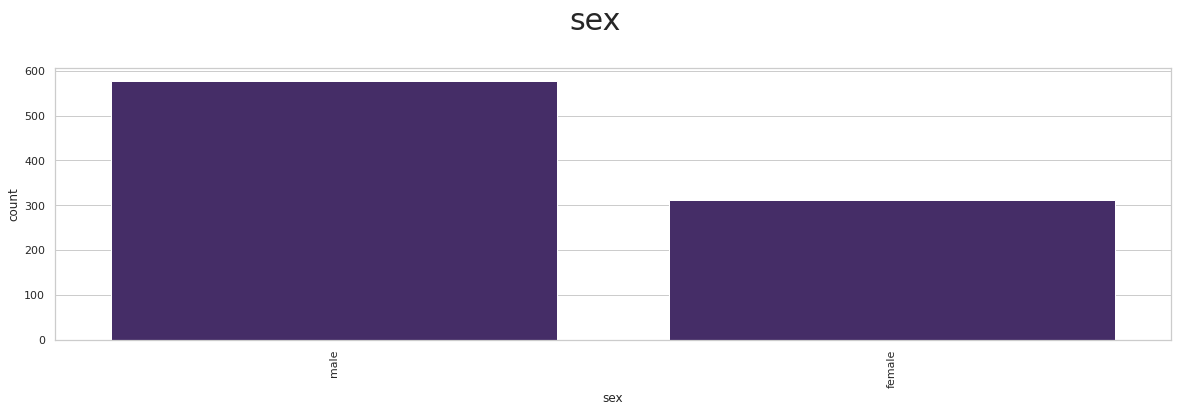

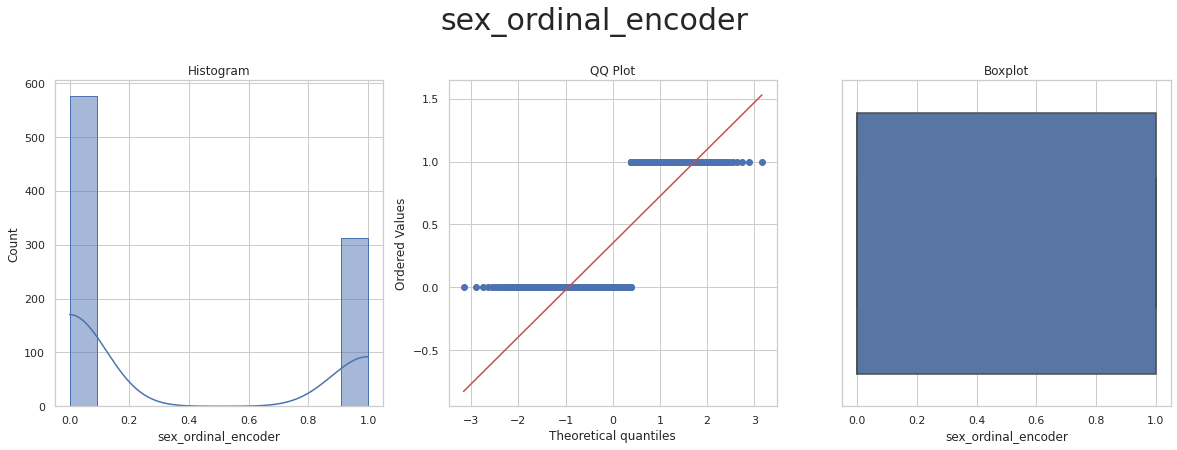



* Variable Analyzed: embarked
* Applied transformation: ['embarked_ordinal_encoder'] 



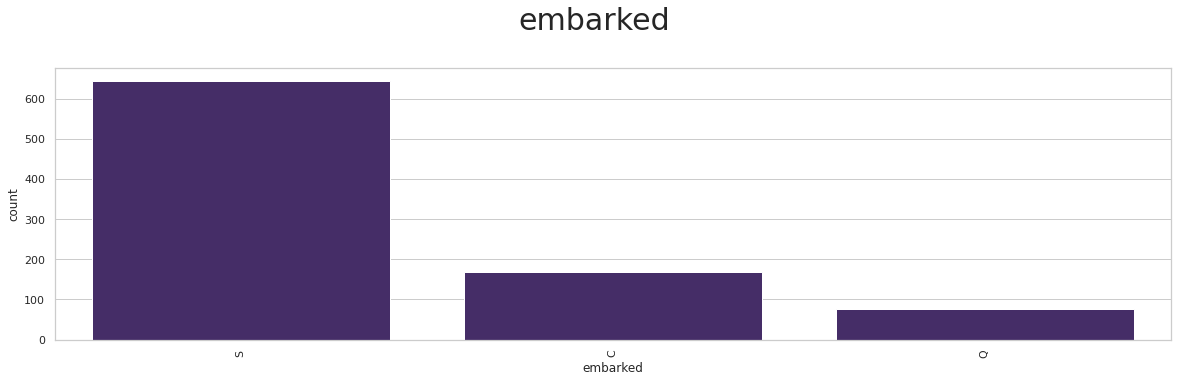

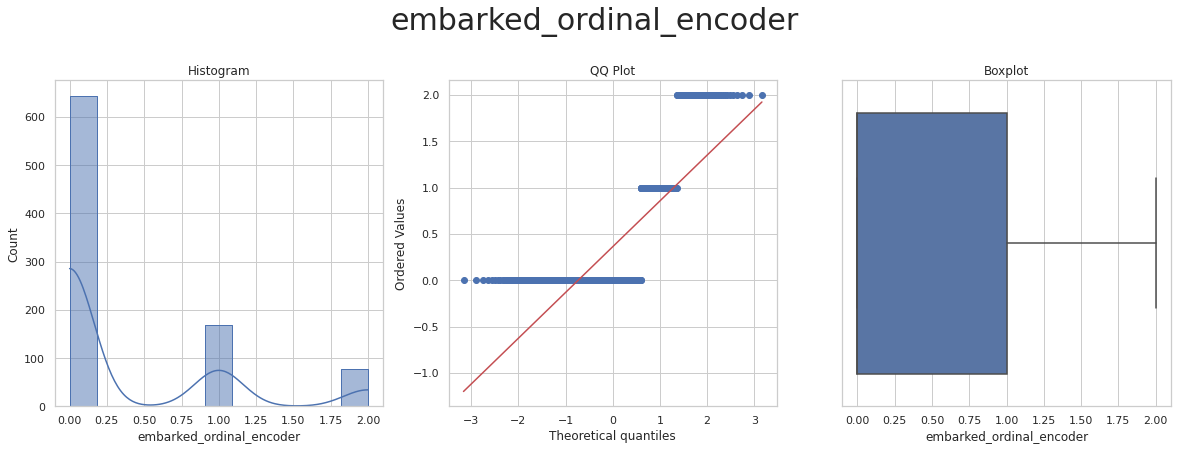



* Variable Analyzed: who
* Applied transformation: ['who_ordinal_encoder'] 



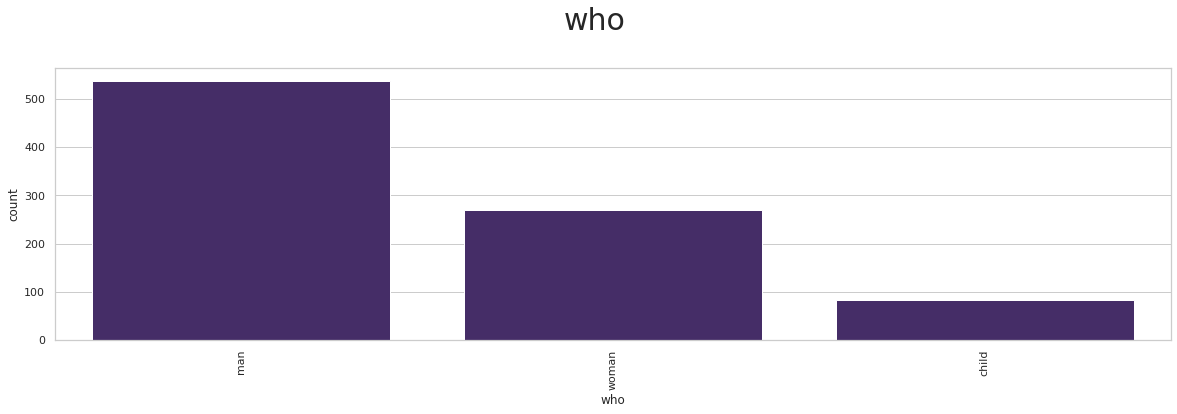

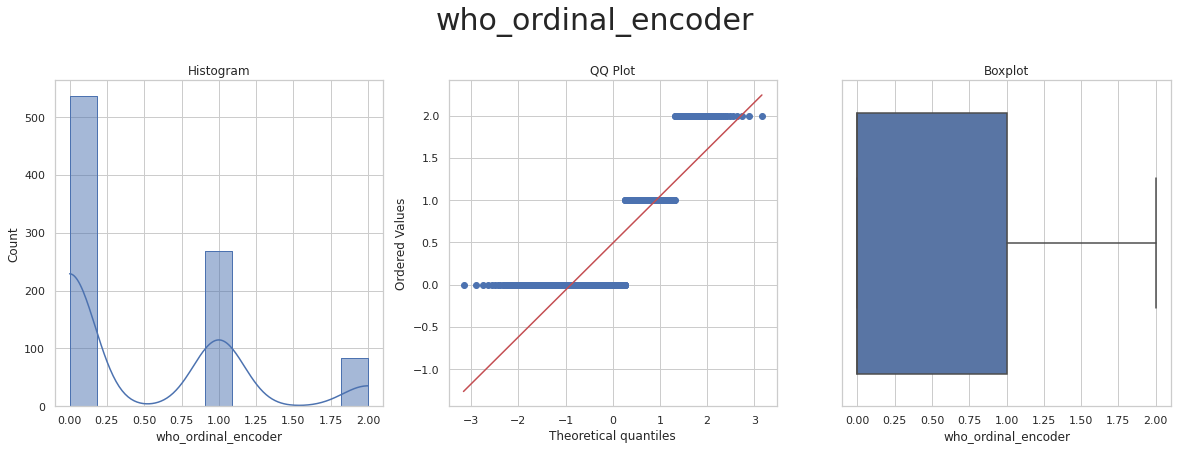



* Variable Analyzed: embark_town
* Applied transformation: ['embark_town_ordinal_encoder'] 



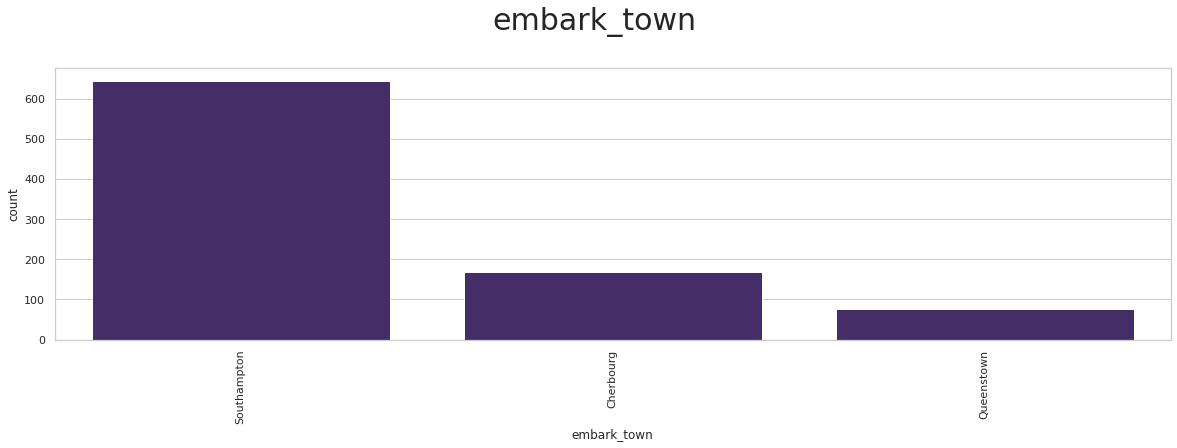

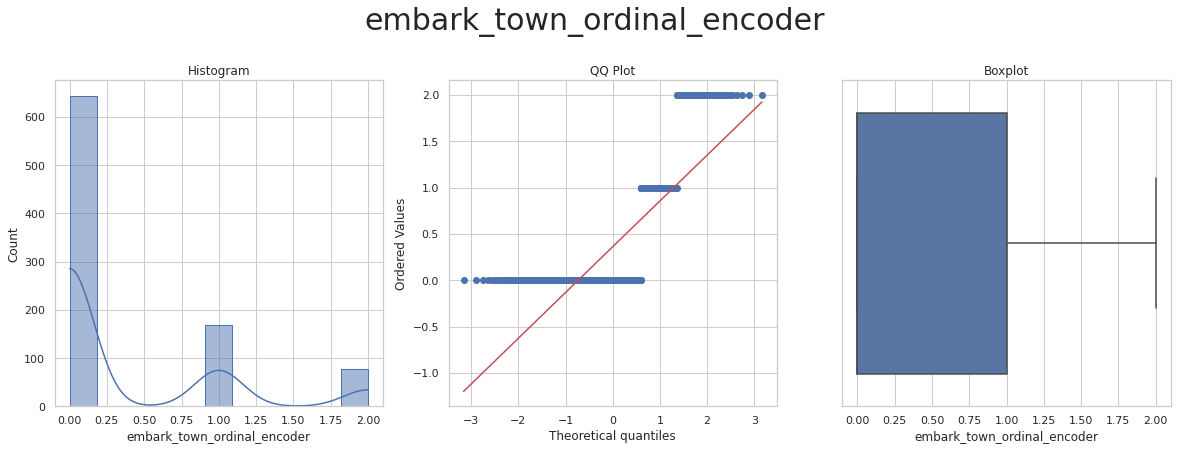

In [23]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering,analysis_type='ordinal_encoder')

---

#### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Outlier 

Again We will assume that at this moment, you are on a project in the workplace, you will know which variables to consider in this outlier analysis

1 - Select variable(s)

In [24]:
variables_engineering = ['age', 'fare']
variables_engineering

['age', 'fare']

2 - Create a separate DataFrame for the variable(s)

In [25]:
df_engineering = df[variables_engineering].copy()
df_engineering.head(3)

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250


3 - Assess engineered variables distribution 
* We note that for both variables, replacing outliers with the IQR method didn't help to become normal distributed but helped to become less abnormal, and this tends to be positive for an ML model. Therefore, you will consider this step in your pipeline when age and fare are features. 

* Variable Analyzed: age
* Applied transformation: ['age_iqr'] 



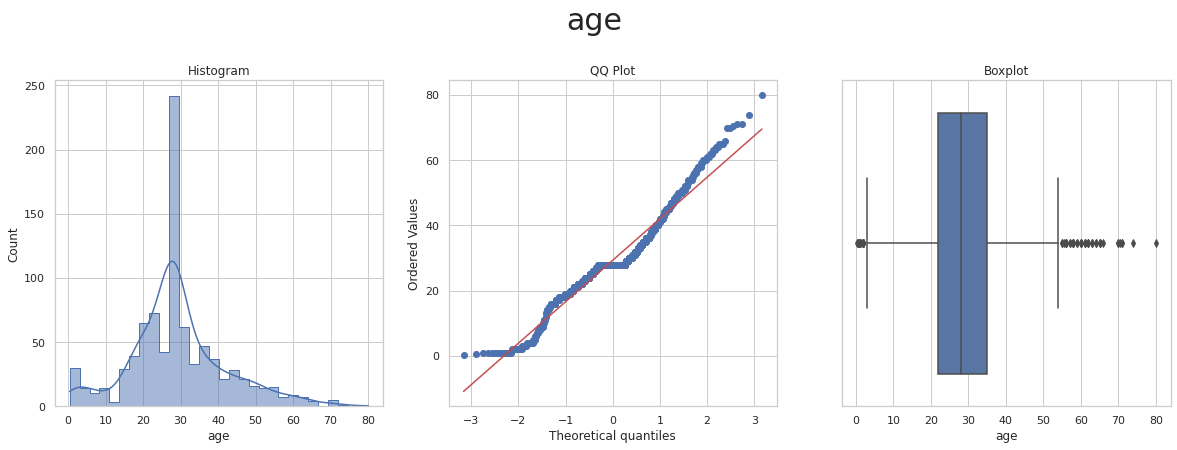

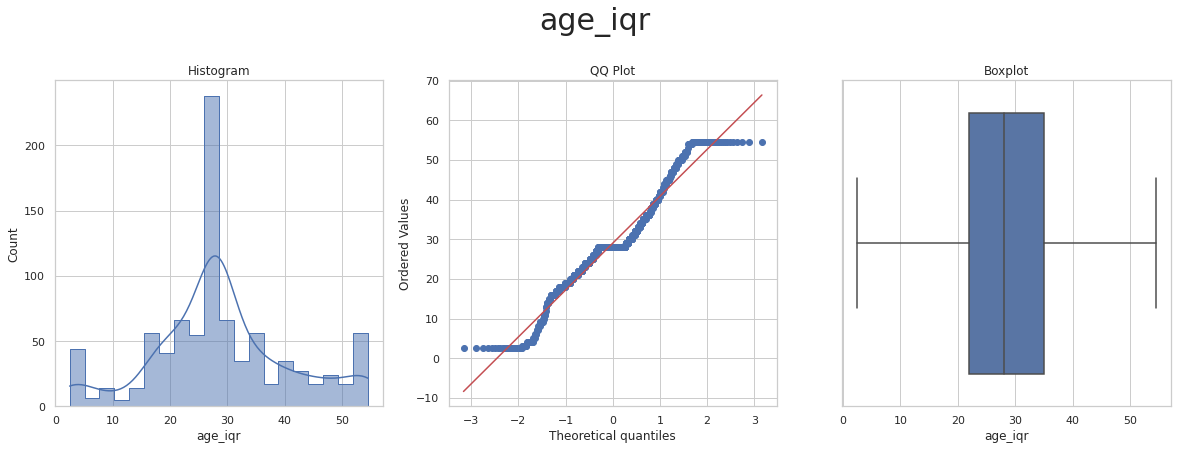



* Variable Analyzed: fare
* Applied transformation: ['fare_iqr'] 



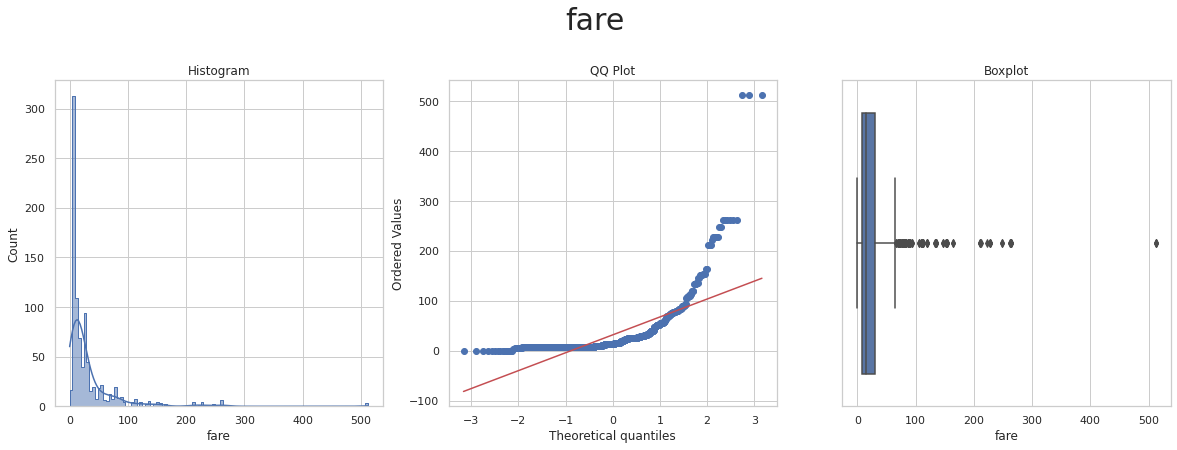

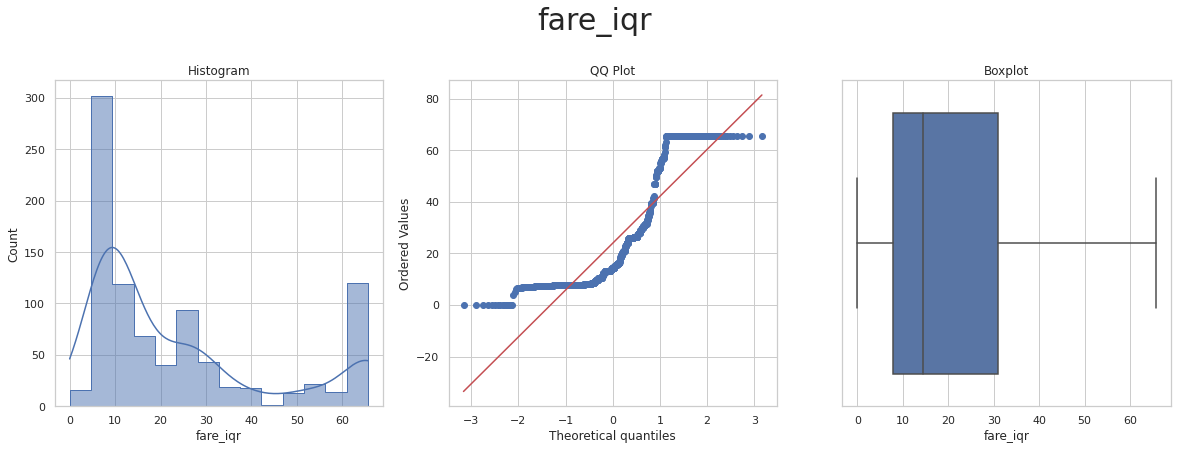

In [26]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering.dropna(),
                                            analysis_type='outlier_winsorizer')

---

#### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Numerical

Again We will assume that at this moment, you are on a project in the workplace, you will know which variables to try numerical transformation

1 - Select variable(s)

In [27]:
variables_engineering= ['fare']
variables_engineering

['fare']

2 - Create a separate DataFrame for the variable(s)

In [28]:
df_engineering = df[variables_engineering].copy()
df_engineering.head(3)

,fare
0,7.2500
1,71.2833
2,7.9250


3 - Assess engineered variables distribution 

* The function will try to transform a variable using the following transformer: Log base e and base 10 Transformer, Power Transformer, Reciprocal Transformer, Box Cox Transformer and Yeo Johnson Transformer. In case it is not possible to compute a given transformation (ex.: log transformation doesn't work for negative values), the function will dismiss that given transformation to that given variable.
* For fare, it was possible only to apply Power Transformer and Yeo Johnson.
* Yeo Johnson has a distribution with fewer outliers, and even closer to being normal distributed, it is better than before. We shall consider this transformer for rare features.

In [ ]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering,analysis_type='numerical')

---